# Dự báo PM2.5 cho Ngày Tiếp Theo (Linear Regression)

**Mục tiêu**: Xây dựng mô hình dự báo PM2.5 cho **ngày tiếp theo** dựa vào dữ liệu hiện tại và các ngày trước

**Phương pháp**:
- Mô hình: Linear Regression
- Metrics đánh giá: MAE (Mean Absolute Error), MAPE (Mean Absolute Percentage Error), RMSE, R²
- **Chiến lược dự báo**: Sử dụng dữ liệu của ngày hôm nay và các ngày trước để dự báo PM2.5 của ngày mai

**Dữ liệu**: `final_combined_data.csv` - dữ liệu đã được làm sạch và kết hợp

## 1. Import Libraries và Load Data

In [85]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [86]:
# Load data
data = pd.read_csv('../processed/final_combined_data.csv')
data['time'] = pd.to_datetime(data['time'])
data = data.sort_values('time').reset_index(drop=True)

print(f"Data shape: {data.shape}")
print(f"Date range: {data['time'].min()} to {data['time'].max()}")
print(f"\nFirst 5 rows:")
data.head()

Data shape: (366, 38)
Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00

First 5 rows:


,time,temperature_avg_C,precipitation_mm,wind_speed_kmh,wind_direction_deg,pressure_hPa,pm10_ugm3,pm2_5_ugm3,uv_index,ozone_ugm3,co_ugm3,co2_ppm,has_any_quality_issues,weather_has_quality_issues,aq_has_quality_issues,aq_co2_ppm_invalid_negative,aq_co2_ppm_missing,aq_co_ugm3_invalid_negative,aq_co_ugm3_missing,aq_ozone_ugm3_invalid_negative,aq_ozone_ugm3_missing,aq_pm10_ugm3_invalid_negative,aq_pm10_ugm3_invalid_range,aq_pm10_ugm3_missing,aq_pm2_5_ugm3_invalid_negative,aq_pm2_5_ugm3_invalid_range,aq_pm2_5_ugm3_missing,aq_pm_invalid_logic,aq_uv_index_invalid_negative,aq_uv_index_invalid_range,aq_uv_index_missing,weather_precipitation_mm_missing,weather_pressure_hPa_invalid_range,weather_pressure_hPa_missing,weather_temperature_avg_C_invalid_range,weather_temperature_avg_C_missing,weather_wind_direction_deg_missing,weather_wind_speed_kmh_missing
0,2024-01-01,28.2,0.0,6.2,NaN,1011.3,59.04,39.50,7.65,58.92,692.62,NaN,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,2024-01-02,28.6,0.0,6.3,NaN,1010.9,58.75,39.01,6.15,66.00,585.96,NaN,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,2024-01-03,28.6,0.0,7.1,NaN,1010.9,44.80,29.48,7.30,60.96,533.12,NaN,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,2024-01-04,28.2,0.0,6.8,NaN,1011.4,42.05,27.40,8.35,78.38,490.00,NaN,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,2024-01-05,27.7,0.0,5.1,NaN,1012.2,43.02,28.22,7.50,65.92,563.21,NaN,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


## 2. Exploratory Data Analysis (EDA)

In [87]:
# Kiểm tra missing values trong các biến quan trọng
important_vars = ['temperature_avg_C', 'pm2_5_ugm3', 'precipitation_mm', 
                  'wind_speed_kmh', 'pressure_hPa', 'pm10_ugm3', 
                  'uv_index', 'ozone_ugm3', 'co_ugm3']

print("Missing values:")
print(data[important_vars].isnull().sum())
print(f"\nBasic statistics:")
data[important_vars].describe()

Missing values:
temperature_avg_C     0
pm2_5_ugm3            0
precipitation_mm     12
wind_speed_kmh        0
pressure_hPa          0
pm10_ugm3             0
uv_index              0
ozone_ugm3            0
co_ugm3               0
dtype: int64

Basic statistics:


,temperature_avg_C,pm2_5_ugm3,precipitation_mm,wind_speed_kmh,pressure_hPa,pm10_ugm3,uv_index,ozone_ugm3,co_ugm3
count,366.000000,366.000000,354.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,29.098361,22.669481,5.097175,10.971038,1009.227596,32.318689,8.832787,54.012240,501.328661
std,1.585706,8.959361,7.236060,3.328307,2.333667,11.460982,2.189215,15.014331,281.290978
min,24.300000,9.110000,0.000000,4.600000,1001.500000,10.380000,2.250000,18.080000,186.120000
25%,28.000000,15.282500,0.000000,8.400000,1007.700000,22.782500,7.512500,42.520000,307.670000
50%,29.000000,21.475000,1.100000,10.550000,1009.000000,30.420000,8.975000,51.940000,425.855000
75%,30.100000,28.742500,8.300000,13.300000,1010.600000,40.550000,10.250000,65.887500,572.112500
max,33.000000,54.400000,44.300000,20.900000,1016.200000,62.540000,13.900000,92.120000,1917.540000


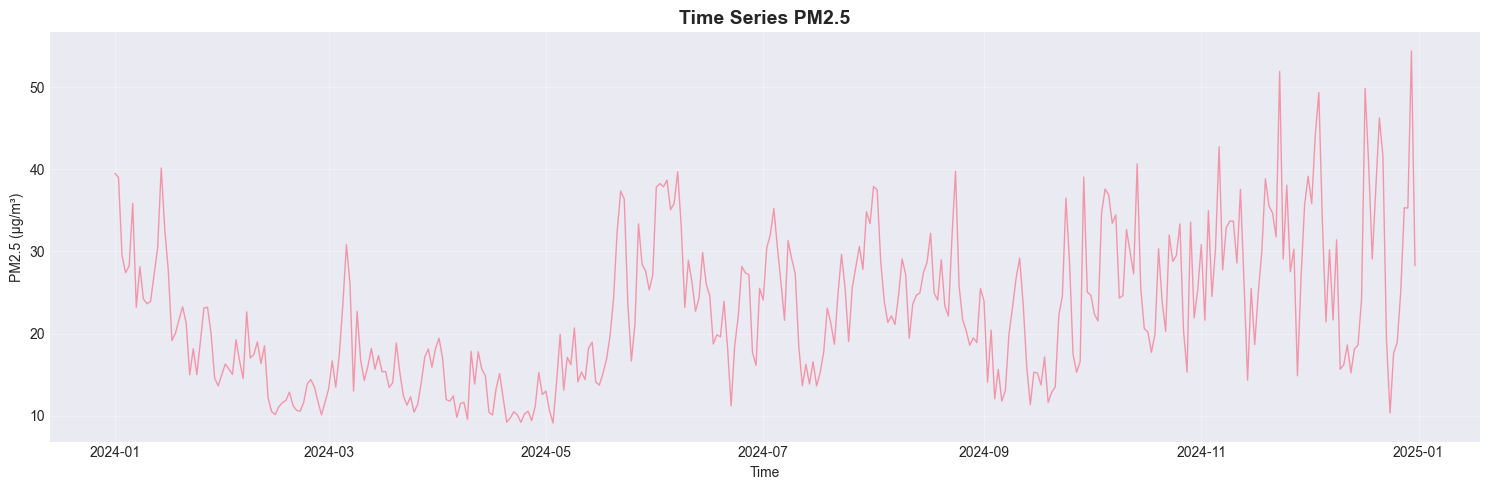

✓ Time series plot saved


In [88]:
# Visualize time series của PM2.5
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data['time'], data['pm2_5_ugm3'], linewidth=1, alpha=0.7)
ax.set_title('Time Series PM2.5', fontsize=14, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('PM2.5 (μg/m³)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/05_timeseries_pm25.pdf', bbox_inches='tight')
plt.show()

print("✓ Time series plot saved")

## 3. Feature Engineering

Tạo các features cho dự báo PM2.5:
- **Lag features**: Giá trị của ngày trước đó (t-1, t-2, t-3)
- **Rolling features**: Trung bình động (3 ngày, 7 ngày)
- **Time features**: Day of week, day of month, month

In [89]:
# Tạo copy để feature engineering
df_fe = data.copy()

# Time-based features (cho ngày tiếp theo)
df_fe['next_day_of_week'] = (df_fe['time'] + pd.Timedelta(days=1)).dt.dayofweek
df_fe['next_day_of_month'] = (df_fe['time'] + pd.Timedelta(days=1)).dt.day
df_fe['next_month'] = (df_fe['time'] + pd.Timedelta(days=1)).dt.month

# Lag features cho PM2.5 (ngày hôm nay, hôm qua, hôm kia)
for i in [1, 2, 3]:
    df_fe[f'pm2_5_lag_{i}'] = df_fe['pm2_5_ugm3'].shift(i)

# Rolling features cho PM2.5
df_fe['pm2_5_rolling_3'] = df_fe['pm2_5_ugm3'].rolling(window=3, min_periods=1).mean()
df_fe['pm2_5_rolling_7'] = df_fe['pm2_5_ugm3'].rolling(window=7, min_periods=1).mean()

# Weather features của ngày hôm nay (dùng làm input để dự báo ngày mai)
df_fe['temp_today'] = df_fe['temperature_avg_C']
df_fe['precip_today'] = df_fe['precipitation_mm']
df_fe['wind_speed_today'] = df_fe['wind_speed_kmh']
df_fe['pressure_today'] = df_fe['pressure_hPa']

# Air quality features của ngày hôm nay
df_fe['pm10_today'] = df_fe['pm10_ugm3']
df_fe['ozone_today'] = df_fe['ozone_ugm3']
df_fe['co_today'] = df_fe['co_ugm3']

# Target: PM2.5 của NGÀY MAI (shift về -1)
df_fe['pm2_5_next_day'] = df_fe['pm2_5_ugm3'].shift(-1)

print(f"Features created. New shape: {df_fe.shape}")
print(f"\nNew columns:")
new_cols = [col for col in df_fe.columns if col not in data.columns]
print(new_cols)
print(f"\n⚠️ Mô hình sẽ dự báo PM2.5 của NGÀY MAI dựa vào dữ liệu của HÔM NAY và các ngày trước")

Features created. New shape: (366, 54)

New columns:
['next_day_of_week', 'next_day_of_month', 'next_month', 'pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_rolling_3', 'pm2_5_rolling_7', 'temp_today', 'precip_today', 'wind_speed_today', 'pressure_today', 'pm10_today', 'ozone_today', 'co_today', 'pm2_5_next_day']

⚠️ Mô hình sẽ dự báo PM2.5 của NGÀY MAI dựa vào dữ liệu của HÔM NAY và các ngày trước


In [90]:
# Drop rows with NaN ONLY in features we will use
# Lag features tạo NaN cho 3 dòng đầu, shift(-1) tạo NaN cho dòng cuối
required_cols = ['pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3',
                 'pm2_5_rolling_3', 'pm2_5_rolling_7',
                 'temp_today', 'precip_today', 'wind_speed_today', 'pressure_today',
                 'pm10_today', 'ozone_today', 'co_today',
                 'next_day_of_week', 'next_day_of_month', 'next_month',
                 'pm2_5_next_day']  # Target

df_fe = df_fe.dropna(subset=required_cols).reset_index(drop=True)
print(f"After dropping NaN in required columns: {df_fe.shape}")
print(f"Date range: {df_fe['time'].min()} to {df_fe['time'].max()}")
print(f"Missing values check:")
print(df_fe[required_cols].isnull().sum().sum(), "total missing values in required columns")
print(f"\n✓ Dữ liệu sẵn sàng: {df_fe.shape[0]} ngày để train/test")

After dropping NaN in required columns: (350, 54)
Date range: 2024-01-04 00:00:00 to 2024-12-30 00:00:00
Missing values check:
0 total missing values in required columns

✓ Dữ liệu sẵn sàng: 350 ngày để train/test


## 4. Xây dựng Model Dự báo PM2.5

### 4.1 Chuẩn bị dữ liệu cho PM2.5

**Target**: `pm2_5_next_day` - PM2.5 của **ngày tiếp theo**

**Features** (dữ liệu của ngày hôm nay và các ngày trước): 
- **PM2.5 lag features**: pm2_5_lag_1 (hôm nay), pm2_5_lag_2 (hôm qua), pm2_5_lag_3 (hôm kia)
- **PM2.5 rolling features**: pm2_5_rolling_3, pm2_5_rolling_7
- **Weather features (hôm nay)**: temp_today, precip_today, wind_speed_today, pressure_today
- **Air quality features (hôm nay)**: pm10_today, ozone_today, co_today
- **Time features (ngày mai)**: next_day_of_week, next_day_of_month, next_month

In [91]:
# Define features cho PM2.5 (dự báo ngày tiếp theo)
pm25_features = [
    # PM2.5 lag features (hôm nay, hôm qua, hôm kia)
    'pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3',
    # PM2.5 rolling features
    'pm2_5_rolling_3', 'pm2_5_rolling_7',
    # Weather features của ngày hôm nay
    'temp_today', 'precip_today', 'wind_speed_today', 'pressure_today',
    # Air quality features của ngày hôm nay
    'pm10_today', 'ozone_today', 'co_today',
    # Time features cho ngày mai
    'next_day_of_week', 'next_day_of_month', 'next_month'
]

X_pm25 = df_fe[pm25_features]
y_pm25 = df_fe['pm2_5_next_day']  # Target: PM2.5 của NGÀY MAI

# Train-test split (80-20, chronological)
split_idx = int(len(df_fe) * 0.8)
X_train_pm25 = X_pm25[:split_idx]
X_test_pm25 = X_pm25[split_idx:]
y_train_pm25 = y_pm25[:split_idx]
y_test_pm25 = y_pm25[split_idx:]

print(f"PM2.5 Model:")
print(f"Train set: {X_train_pm25.shape[0]} samples")
print(f"Test set: {X_test_pm25.shape[0]} samples")
print(f"Features: {len(pm25_features)}")
print(f"\nFeatures list:")
for i, f in enumerate(pm25_features, 1):
    print(f"  {i}. {f}")

PM2.5 Model:
Train set: 280 samples
Test set: 70 samples
Features: 15

Features list:
  1. pm2_5_lag_1
  2. pm2_5_lag_2
  3. pm2_5_lag_3
  4. pm2_5_rolling_3
  5. pm2_5_rolling_7
  6. temp_today
  7. precip_today
  8. wind_speed_today
  9. pressure_today
  10. pm10_today
  11. ozone_today
  12. co_today
  13. next_day_of_week
  14. next_day_of_month
  15. next_month


### 4.2 Train Linear Regression Model

In [92]:
# Train model
model_pm25 = LinearRegression()
model_pm25.fit(X_train_pm25, y_train_pm25)

# Predictions
y_train_pred_pm25 = model_pm25.predict(X_train_pm25)
y_test_pred_pm25 = model_pm25.predict(X_test_pm25)

print("✓ PM2.5 model trained successfully")
print(f"Model coefficients: {len(model_pm25.coef_)} features")
print(f"Intercept: {model_pm25.intercept_:.4f}")

✓ PM2.5 model trained successfully
Model coefficients: 15 features
Intercept: -212.4173


### 4.3 Đánh giá Model

In [93]:
# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE, handling zero values"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    non_zero_idx = y_true != 0
    if non_zero_idx.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[non_zero_idx] - y_pred[non_zero_idx]) / y_true[non_zero_idx])) * 100

# Evaluation metrics
def evaluate_model(y_true, y_pred, dataset_name=""):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name} Metrics:")
    print(f"  MAE:  {mae:.4f} μg/m³")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  RMSE: {rmse:.4f} μg/m³")
    print(f"  R²:   {r2:.4f}")
    
    return {'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2}

# Evaluate PM2.5 model
print("="*60)
print("PM2.5 FORECASTING MODEL EVALUATION")
print("="*60)

pm25_train_metrics = evaluate_model(y_train_pm25, y_train_pred_pm25, "Training Set")
pm25_test_metrics = evaluate_model(y_test_pm25, y_test_pred_pm25, "Test Set")

PM2.5 FORECASTING MODEL EVALUATION

Training Set Metrics:
  MAE:  3.4094 μg/m³
  MAPE: 16.84%
  RMSE: 4.5018 μg/m³
  R²:   0.6754

Test Set Metrics:
  MAE:  8.3564 μg/m³
  MAPE: 32.71%
  RMSE: 10.5557 μg/m³
  R²:   -0.2837


## 5. Visualization và Phân tích kết quả

### 5.1 PM2.5 Predictions vs Actual

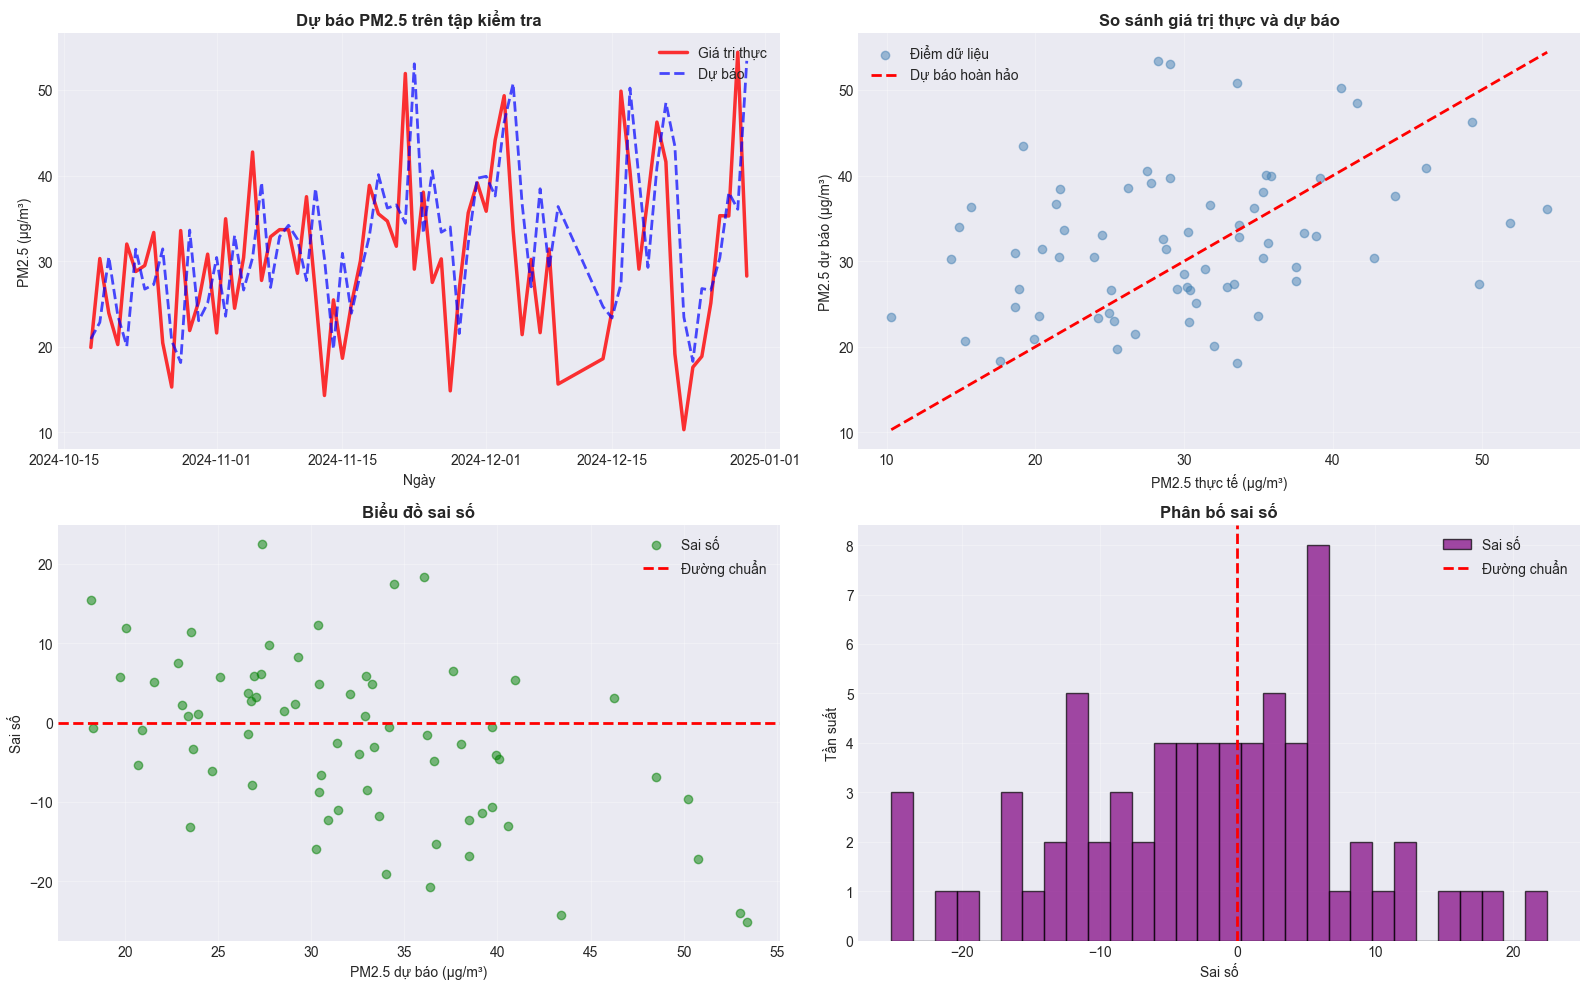

✓ PM2.5 prediction plots saved


In [94]:
# PM2.5: Actual vs Predicted on Test Set
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Test set time series
test_dates = df_fe['time'].iloc[split_idx:].values
axes[0, 0].plot(test_dates, y_test_pm25.values, label='Giá trị thực', linewidth=2.5, color='red', alpha=0.8)
axes[0, 0].plot(test_dates, y_test_pred_pm25, label='Dự báo', linewidth=2, color='blue', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Dự báo PM2.5 trên tập kiểm tra', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Ngày')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].legend(loc='upper right', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Scatter plot: Actual vs Predicted
axes[0, 1].scatter(y_test_pm25, y_test_pred_pm25, alpha=0.5, label='Điểm dữ liệu', color='steelblue')
axes[0, 1].plot([y_test_pm25.min(), y_test_pm25.max()], 
                [y_test_pm25.min(), y_test_pm25.max()], 
                'r--', linewidth=2, label='Dự báo hoàn hảo')
axes[0, 1].set_title('So sánh giá trị thực và dự báo', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('PM2.5 thực tế (μg/m³)')
axes[0, 1].set_ylabel('PM2.5 dự báo (μg/m³)')
axes[0, 1].legend(loc='upper left', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Residuals
residuals_pm25 = y_test_pm25.values - y_test_pred_pm25
axes[1, 0].scatter(y_test_pred_pm25, residuals_pm25, alpha=0.5, label='Sai số', color='green')
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Đường chuẩn')
axes[1, 0].set_title('Biểu đồ sai số', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('PM2.5 dự báo (μg/m³)')
axes[1, 0].set_ylabel('Sai số')
axes[1, 0].legend(loc='upper right', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Residuals distribution
axes[1, 1].hist(residuals_pm25, bins=30, edgecolor='black', alpha=0.7, label='Sai số', color='purple')
axes[1, 1].set_title('Phân bố sai số', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sai số')
axes[1, 1].set_ylabel('Tần suất')
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Đường chuẩn')
axes[1, 1].legend(loc='upper right', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/05_pm25_predictions.pdf', bbox_inches='tight')
plt.show()

print("✓ PM2.5 prediction plots saved")

### 5.2 Feature Importance Analysis

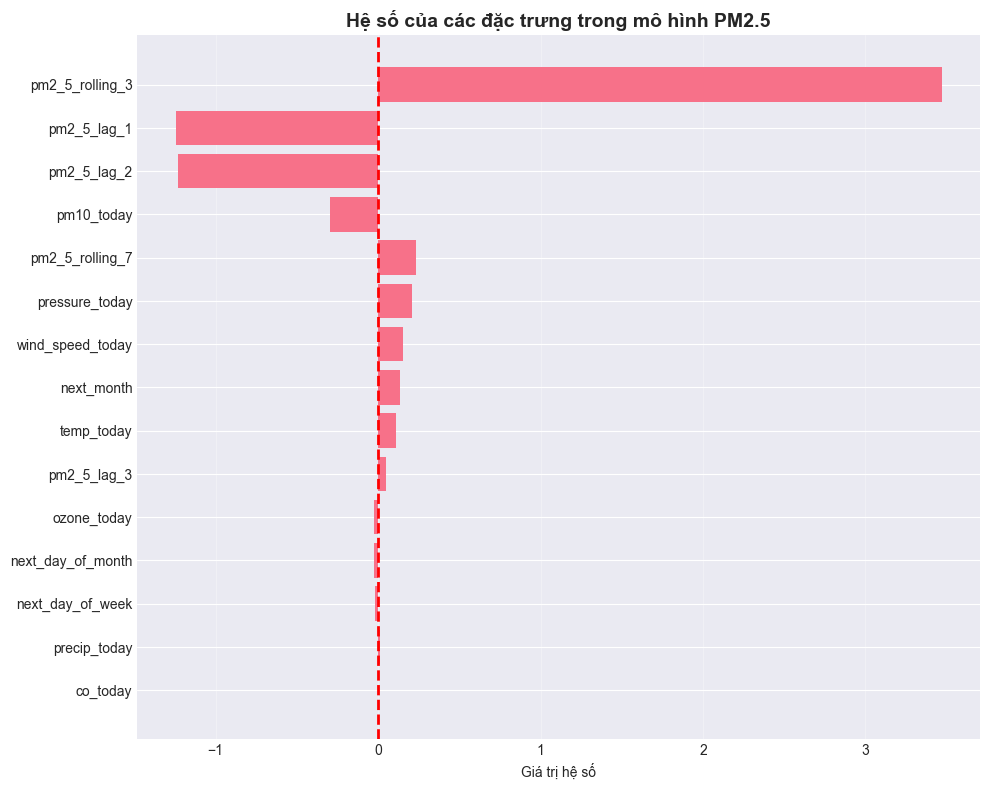

✓ Feature importance plot saved

Top 10 Most Important Features:
         feature  coefficient  abs_coef
 pm2_5_rolling_3     3.468972  3.468972
     pm2_5_lag_1    -1.245627  1.245627
     pm2_5_lag_2    -1.232255  1.232255
      pm10_today    -0.294507  0.294507
 pm2_5_rolling_7     0.231100  0.231100
  pressure_today     0.209500  0.209500
wind_speed_today     0.153220  0.153220
      next_month     0.133044  0.133044
      temp_today     0.110546  0.110546
     pm2_5_lag_3     0.049438  0.049438


In [95]:
# Feature importance (based on coefficients magnitude)
fig, ax = plt.subplots(figsize=(10, 8))

# PM2.5 Feature Importance
pm25_importance = pd.DataFrame({
    'feature': pm25_features,
    'coefficient': model_pm25.coef_
})
pm25_importance['abs_coef'] = pm25_importance['coefficient'].abs()
pm25_importance = pm25_importance.sort_values('abs_coef', ascending=True)

ax.barh(pm25_importance['feature'], pm25_importance['coefficient'])
ax.set_title('Hệ số của các đặc trưng trong mô hình PM2.5', fontsize=14, fontweight='bold')
ax.set_xlabel('Giá trị hệ số')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../figures/05_feature_importance.pdf', bbox_inches='tight')
plt.show()

print("✓ Feature importance plot saved")

# Display top 10 most important features
print("\nTop 10 Most Important Features:")
print(pm25_importance.sort_values('abs_coef', ascending=False)[['feature', 'coefficient', 'abs_coef']].head(10).to_string(index=False))

### 5.3 Summary Table

In [96]:
# Create summary table
summary_data = {
    'Metric': ['Train Size', 'Test Size', 'Number of Features', 'MAE', 'MAPE (%)', 'RMSE', 'R²'],
    'Training Set': [
        len(X_train_pm25),
        '-',
        len(pm25_features),
        f"{pm25_train_metrics['MAE']:.4f}",
        f"{pm25_train_metrics['MAPE']:.2f}",
        f"{pm25_train_metrics['RMSE']:.4f}",
        f"{pm25_train_metrics['R2']:.4f}"
    ],
    'Test Set': [
        '-',
        len(X_test_pm25),
        '-',
        f"{pm25_test_metrics['MAE']:.4f}",
        f"{pm25_test_metrics['MAPE']:.2f}",
        f"{pm25_test_metrics['RMSE']:.4f}",
        f"{pm25_test_metrics['R2']:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("PM2.5 FORECASTING MODEL SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Save detailed results to CSV
results_df = pd.DataFrame({
    'Dataset': ['Training', 'Test'],
    'Size': [len(X_train_pm25), len(X_test_pm25)],
    'MAE': [pm25_train_metrics['MAE'], pm25_test_metrics['MAE']],
    'MAPE': [pm25_train_metrics['MAPE'], pm25_test_metrics['MAPE']],
    'RMSE': [pm25_train_metrics['RMSE'], pm25_test_metrics['RMSE']],
    'R2': [pm25_train_metrics['R2'], pm25_test_metrics['R2']]
})
results_df.to_csv('../reports/pm25_forecasting_results.csv', index=False)
print("\n✓ Results saved to ../reports/pm25_forecasting_results.csv")


PM2.5 FORECASTING MODEL SUMMARY
            Metric Training Set Test Set
        Train Size          280        -
         Test Size            -       70
Number of Features           15        -
               MAE       3.4094   8.3564
          MAPE (%)        16.84    32.71
              RMSE       4.5018  10.5557
                R²       0.6754  -0.2837

✓ Results saved to ../reports/pm25_forecasting_results.csv


## 6. Kết luận

### Kết quả chính:

**PM2.5 Forecasting Model:**
- Sử dụng Linear Regression để dự báo PM2.5 ngày tiếp theo
- Model dựa trên lag features, rolling averages, weather features, và time features
- Đánh giá toàn diện qua 4 metrics: MAE, MAPE, RMSE, R²

### Ý nghĩa của các Metrics:

1. **MAE (Mean Absolute Error)**: Sai số tuyệt đối trung bình (μg/m³)
   - Cho biết trung bình mô hình sai lệch bao nhiêu so với giá trị thực
   - Giá trị càng nhỏ càng tốt

2. **MAPE (Mean Absolute Percentage Error)**: Sai số phần trăm tuyệt đối trung bình (%)
   - Đo lường sai số theo tỷ lệ phần trăm
   - Dễ hiểu và so sánh giữa các bài toán khác nhau
   - < 10%: Rất tốt | 10-20%: Tốt | 20-50%: Chấp nhận được | > 50%: Kém

3. **RMSE (Root Mean Square Error)**: Căn bậc hai của sai số bình phương trung bình (μg/m³)
   - Phạt nặng các sai số lớn hơn MAE
   - Hữu ích khi outliers quan trọng

4. **R² (Coefficient of Determination)**: Hệ số xác định (0-1)
   - Tỷ lệ phương sai được giải thích bởi mô hình
   - R² = 1: Hoàn hảo | R² > 0.7: Tốt | R² > 0.5: Chấp nhận được

### Điểm mạnh của phương pháp:

1. **Minh bạch**: Linear Regression dễ hiểu, dễ giải thích
2. **Tái lập (Reproducible)**: Code rõ ràng, có thể chạy lại
3. **Đánh giá đầy đủ**: Nhiều metrics từ nhiều góc độ
4. **Feature Engineering có ý nghĩa**: Lag và rolling features phù hợp với time series

### Hạn chế và hướng cải thiện:

1. **Giả định tuyến tính**: Linear Regression giả định mối quan hệ tuyến tính
   - Cải thiện: Thử Random Forest, XGBoost, Neural Networks
   
2. **Seasonality**: Chưa xử lý đầy đủ seasonal patterns
   - Cải thiện: Thêm seasonal decomposition, thử SARIMA
   
3. **Feature Engineering**: Có thể mở rộng
   - Cải thiện: Interaction features, polynomial features, weather lag features

4. **Cross-validation**: Chỉ dùng 1 lần split
   - Cải thiện: Time series cross-validation

### Files được tạo:

- `../figures/05_timeseries_pm25.pdf` - Biểu đồ time series
- `../figures/05_pm25_predictions.pdf` - Dự báo vs thực tế
- `../figures/05_feature_importance.pdf` - Tầm quan trọng của features
- `../reports/pm25_forecasting_results.csv` - Kết quả chi tiết

---